Импортирую модули и загружаю данные.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from scipy import sparse
import umap.umap_ as umap

X = sparse.load_npz("train.npz")

Предобрабатываю данные.

Использую standart scaler без среднего, тк иначе матрица перестанет быть разреженной.
Через pca уменьшаю размерность до 50 тк при таком значении, накопительная сумма дисперсии всё ещё примерно равна 0.99.
Дважды понижаю размерность через umap, чтобы более явно выделить близкие элементы и разделить более отдалённые. Гиперпараметры для umap я подбирал с помощью optuna, максимизируя silhouette score.

In [ ]:
pipe = make_pipeline(StandardScaler(with_mean=False),
                     TruncatedSVD(n_components=50, random_state=42),
                     umap.UMAP(metric='chebyshev', n_components=10,
                               n_neighbors=11, min_dist=0.0, random_state=42),
                     umap.UMAP(metric='chebyshev', n_components=2,
                               n_neighbors=11, min_dist=0.0, random_state=42)
                     )

X_preprocessed = pipe.fit_transform(X)

Использую dbscan, тк он не требует указывать количество кластеров, и наиболее верно разделяет данные, судя по графику.

Silhouette Score: 0.6154651


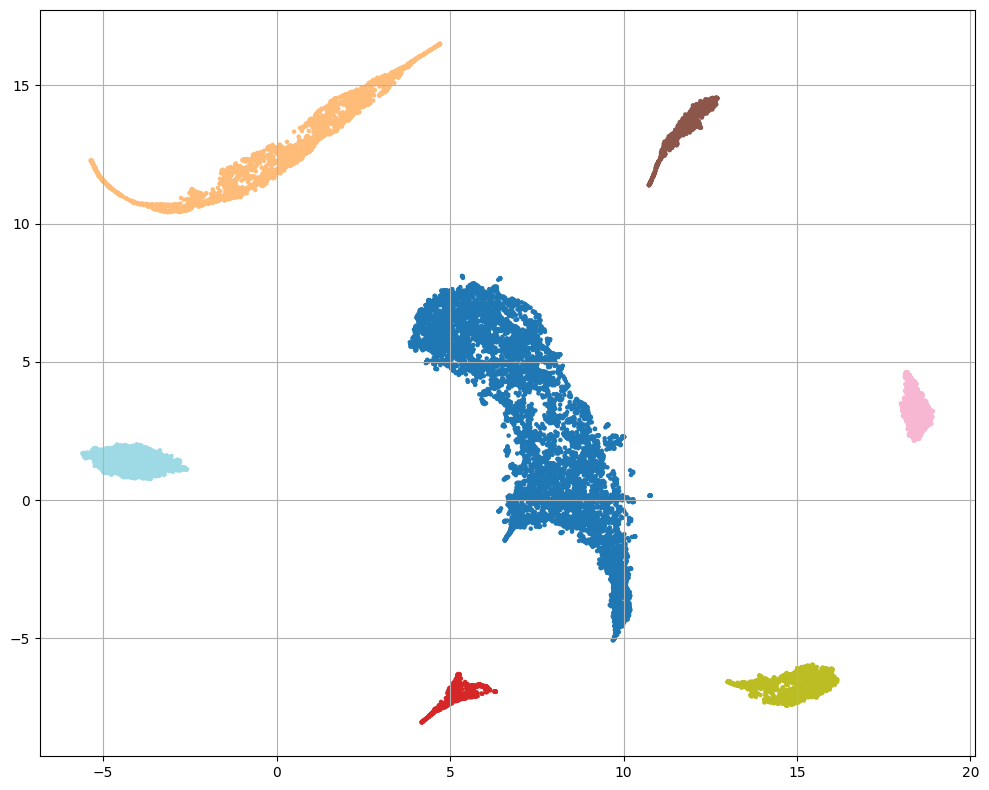

In [3]:
clusterer = DBSCAN()
labels = clusterer.fit_predict(X_preprocessed)

score = silhouette_score(X_preprocessed, labels)
print("Silhouette Score:", score)

plt.figure(figsize=(10, 8))
plt.scatter(X_preprocessed[:, 0], X_preprocessed[:,
            1], c=labels, cmap='tab20', s=5)
plt.grid(True)
plt.tight_layout()
plt.show()

Сохраняю данные.

In [4]:
df = pd.DataFrame({
    "ID": np.arange(X.shape[0]),
    "TARGET": labels
})
df.to_csv("submission.csv", index=False)